
[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.
c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\admin\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environ

Embedding shape: (10, 384)


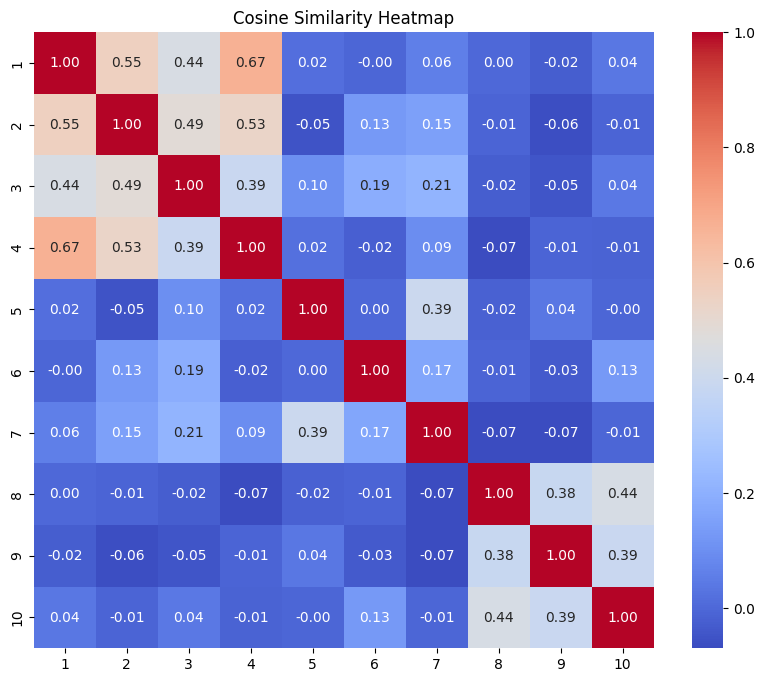


Query: The bowler took three wickets in one over

Sentence: The bowler delivered a perfect yorker to take the wicket.
Similarity Score: 0.6850507

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.56791204


In [1]:
# Step 1: Install sentence-transformers
!pip install -q sentence-transformers

# Step 2: Import libraries
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Step 3: Define 10 sentences across 3 topics
sentences = [
    # Cricket
    "The cricket match was thrilling until the last over.",
    "The batsman scored a century in the final match.",
    "The bowler delivered a perfect yorker to take the wicket.",
    "The team celebrated their victory after the intense cricket match.",

    # Cooking
    "I love cooking pasta with fresh tomato sauce.",
    "Baking a chocolate cake requires precise measurements.",
    "The chef prepared a delicious meal using fresh vegetables.",

    # Cybersecurity
    "Cybersecurity protects systems from digital attacks.",
    "Strong passwords help prevent unauthorized access.",
    "Phishing attacks trick users into revealing sensitive information."
]

# Step 4: Load sentence-transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 5: Generate embeddings
embeddings = model.encode(sentences)
print("Embedding shape:", embeddings.shape)

# Step 6: Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Step 7: Display similarity matrix as DataFrame
df = pd.DataFrame(similarity_matrix, columns=range(1,11), index=range(1,11))
df

# Step 8: Visualize similarity matrix as heatmap
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=range(1,11), yticklabels=range(1,11))
plt.title("Cosine Similarity Heatmap")
plt.show()

# Step 9: Find top 2 similar sentences for a query
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

query_similarity = cosine_similarity(query_embedding, embeddings)[0]
top_indices = np.argsort(query_similarity)[-2:][::-1]

print("\nQuery:", query)
for i in top_indices:
    print("\nSentence:", sentences[i])
    print("Similarity Score:", query_similarity[i])